# Proyecto 2 IA 

Ing. Luis Suriano

- Vianka Castro 23201
- Ricardo Godinez 23247



## Task 1 Configuración Segura de la Red (CSP y Factor Graphs)

Primero vamos a modelar los grafos, esto asignandoles nodos hermanos. Luego  vamos a asignar protocolos de seguridad a cada nodo. Tenemos 4 protocolos de seguridad disponibles (representados por colores: Rojo, Verde, Azul, Amarillo).

### 1. Modelado: Defina formalmente este problema como un Problema de Satisfacción de Restricciones
(CSP) usando Factor Graphs. ¿Cuáles son sus variables, dominios y factores?

**Variables $X$**:

Las variable son entidades del problema a las que vamos a tener que asignarle un valor. En el caso del proyecto seran los servidores de red.

$X = \{S_0, S_1, S_2, \dots, S_n\}$

Donde n es el numero de nodos generados aleatoriamente

**Dominio $D$**:

El dominio es el conjunto de opciones que puede tomar cada variable, son los 4 protocolos de seguridad disponibles

Para toda variable $S_i$, su dominio inicial es $D_i = \{Rojo, Verde, Azul, Amarillo\}$

**Factores o Restrcciones $D$**:

Este es el concepto de **Factor Graph**. Es un grafo de factores, las reglas del mundo evaluando si es valida o no. En nuestro caso la restriccion fisica de la red es evitar vulnelabilidafes teniendo dos nodos hermanos con el mismo protocolo de red. 

$$
\phi(S_i, S_j) = \begin{cases} 
1 & \text{si } S_i \neq S_j \\ 
0 & \text{si } S_i = S_j 
\end{cases}
$$


### 2. Implementación: Programe desde cero el algoritmo de Backtracking Search.

=== Lista de nodos y conecciones entre ellos
Numero de nodos 17 Numero de vertices 43


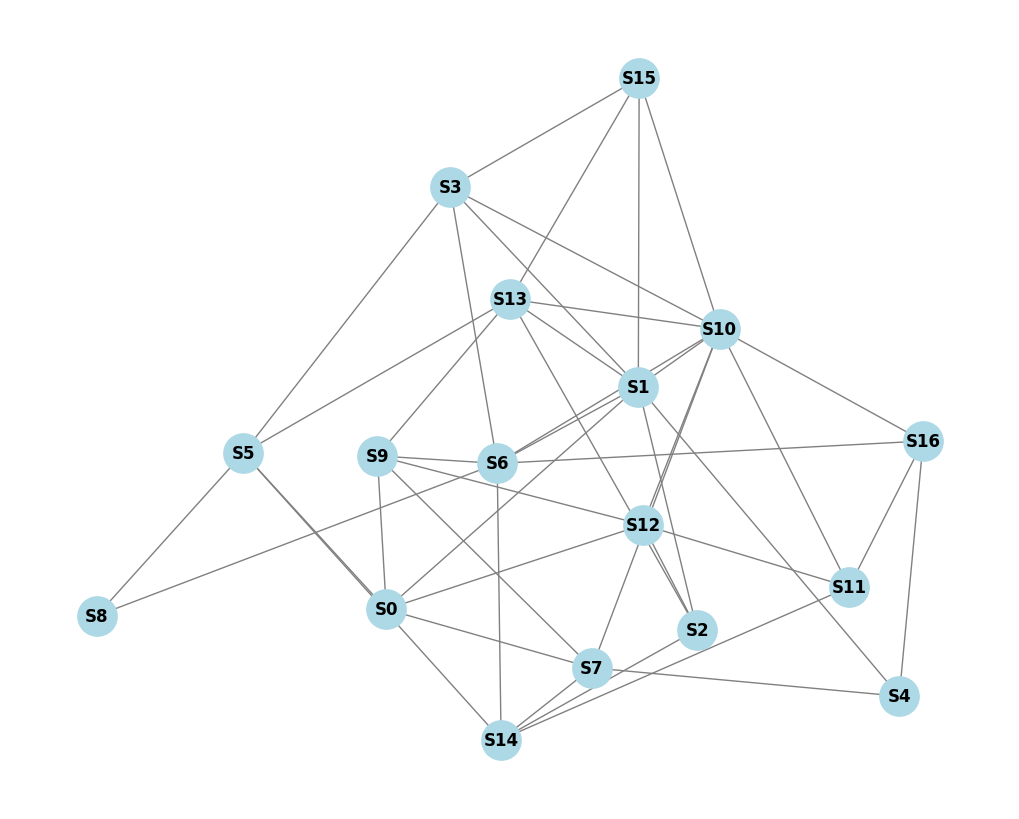

In [41]:
import random
import time
import copy
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

num_nodos = 17
lista_nodos = []

#Creacion de nodos de manera random
for i in range (num_nodos):lista_nodos.append(f"S{i}")

G = nx.Graph()
G.add_nodes_from(lista_nodos)

probabilidad_hermanos = 0.3

# De forma random asignamos a los nodos la probabilidad que un nodo sea su hermano o no
for i in range(num_nodos):
    for j in range(i + 1, num_nodos):
        if random.random() < probabilidad_hermanos:
            G.add_edge(f"S{i}", f"S{j}")

print("=== Lista de nodos y conecciones entre ellos")
print(f"Numero de nodos {G.number_of_nodes()} Numero de vertices {G.number_of_edges()}")
plt.figure(figsize=(10, 8))
nx.draw(G, 
        with_labels=True,        
        node_color='lightblue',  
        node_size=800,           
        font_weight='bold',      
        edge_color='gray')

plt.show()


In [44]:
#Validamos si el protocolo de color que queremos usar ya esta siendo ocupado por un nodo hermano
def es_valido(nodo, color, asignaciones, grafo):
    for vecino in grafo.neighbors(nodo):
        if vecino in asignaciones and asignaciones[vecino] == color:
            return False
    return True

#Definimos el algoritmo de backtracking puro
def backtracking_puro(asignaciones, nodos_pendientes, dominios, grafo):
    if len(asignaciones) == grafo.number_of_nodes():
        return asignaciones

    nodo_actual = nodos_pendientes[0]

    for color in dominios[nodo_actual]:
        if es_valido(nodo_actual, color, asignaciones, grafo):
            asignaciones[nodo_actual] = color
            
            resultado = backtracking_puro(asignaciones, nodos_pendientes[1:], dominios, grafo)
            
            if resultado is not None:
                return resultado

            del asignaciones[nodo_actual]

    return None


protocolos = ["Rojo", "Verde", "Azul", "Amarillo"]
dominios = {}
for nodo in G.nodes():
    dominios[nodo] = protocolos.copy()

asignaciones_iniciales = {}
lista_nodos_pendientes = list(G.nodes())

solucion = backtracking_puro(asignaciones_iniciales, lista_nodos_pendientes, dominios, G)

print("Resultado de la configuración:", solucion)

Resultado de la configuración: {'S0': 'Rojo', 'S1': 'Verde', 'S2': 'Rojo', 'S3': 'Azul', 'S4': 'Rojo', 'S5': 'Verde', 'S6': 'Rojo', 'S7': 'Verde', 'S8': 'Azul', 'S9': 'Amarillo', 'S10': 'Amarillo', 'S11': 'Rojo', 'S12': 'Verde', 'S13': 'Azul', 'S14': 'Azul', 'S15': 'Rojo', 'S16': 'Verde'}


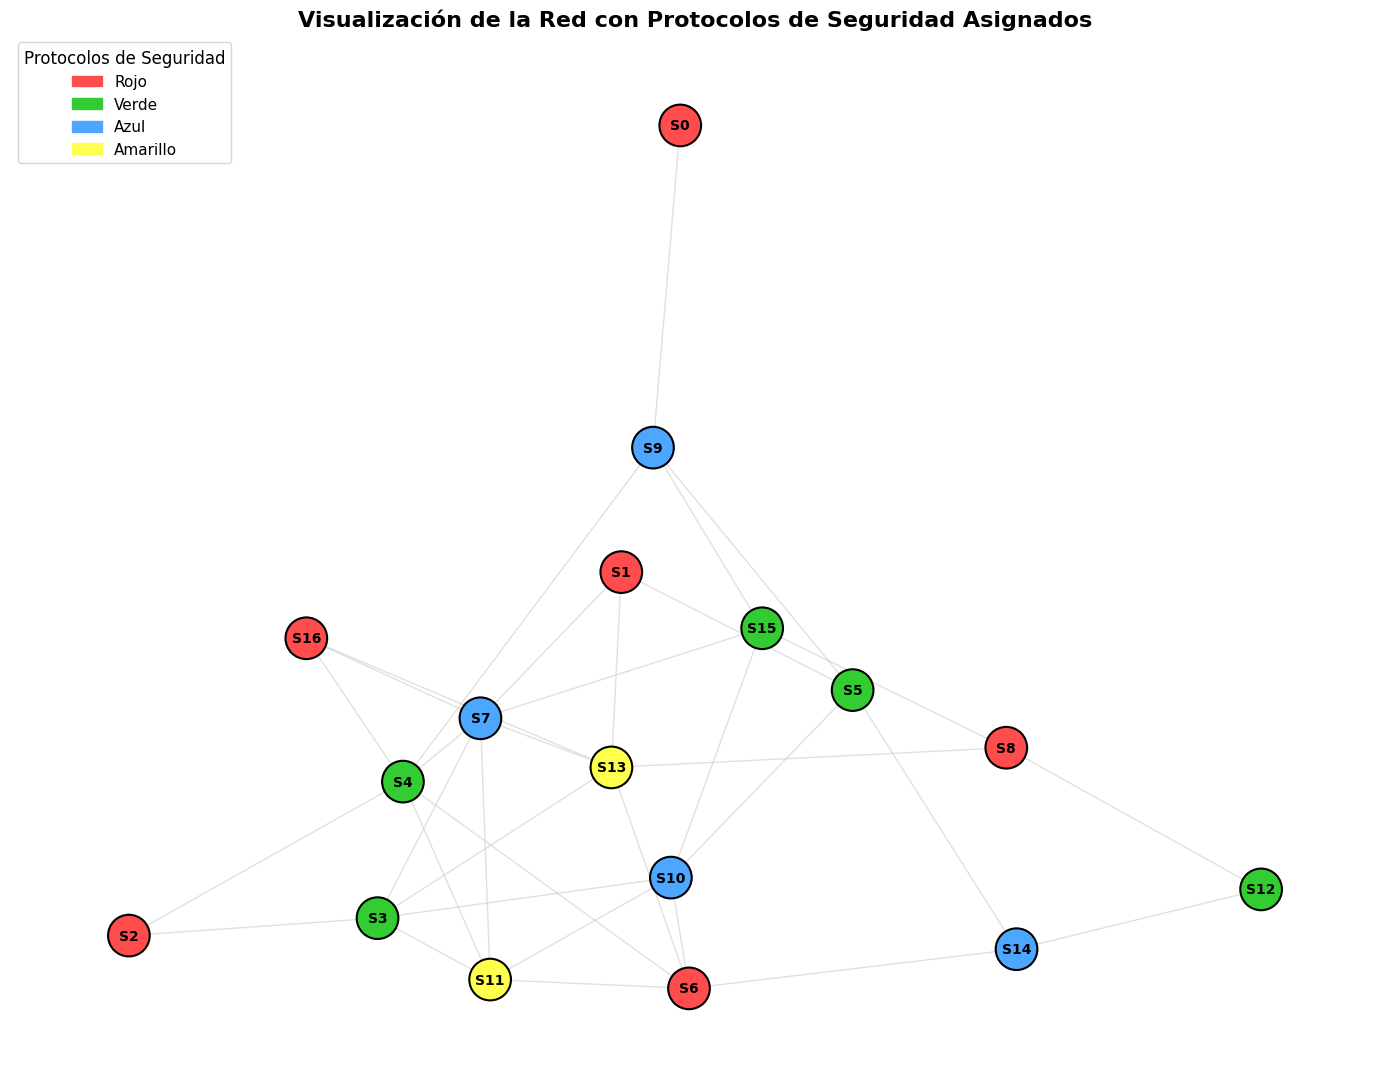

In [37]:
mapa_colores_visual = {
    "Rojo": "#ff4d4d",    
    "Verde": "#33cc33",    
    "Azul": "#4da6ff",     
    "Amarillo": "#ffff4d"  
}

lista_colores_nodos = []

for nodo in G.nodes():
    color_asignado_es = solucion[nodo]
    
    color_matplot = mapa_colores_visual[color_asignado_es] 
    lista_colores_nodos.append(color_matplot)

plt.figure(figsize=(14, 11))
plt.title("Visualización de la Red con Protocolos de Seguridad Asignados", fontsize=16, fontweight='bold')
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_edges(G, pos, 
                       edge_color='#cccccc', 
                       width=1.0, 
                       alpha=0.6)

nx.draw_networkx_nodes(G, pos, 
                       node_color=lista_colores_nodos,
                       node_size=900, 
                       edgecolors='black',
                       linewidths=1.5)

nx.draw_networkx_labels(G, pos, 
                        font_size=10, 
                        font_family='sans-serif', 
                        font_weight='bold',
                        font_color='black') 


patches_leyenda = []
for protocolo, color_hex in mapa_colores_visual.items():
    parche = mpatches.Patch(color=color_hex, label=protocolo)
    patches_leyenda.append(parche)

plt.legend(handles=patches_leyenda, title="Protocolos de Seguridad", fontsize=11, title_fontsize=12, loc='upper left')

plt.axis('off') 
plt.tight_layout() 
plt.show()

### 3. Optimización: Su algoritmo básico será muy lento. Debe implementar obligatoriamente:

a. Lookahead (Forward Checking): Para eliminar dominios inconsistentes de los vecinos.

b. Heurística MCV (Minimum Remaining Values / Variable más restringida): Para elegir el siguiente nodo a asignar.

In [45]:
def backtracking_optimizado(grafo, dominios, nodos_pendientes, asignaciones):
    if not nodos_pendientes:
        return asignaciones

    nodo_actual = min(nodos_pendientes, key=lambda n: len(dominios[n]))
    nodos_pendientes = [n for n in nodos_pendientes if n != nodo_actual]

    for color in dominios[nodo_actual]:
        dominios_futuros = copy.deepcopy(dominios)
        falla_futura = False
    
        for vecino in grafo.neighbors(nodo_actual):
            if vecino in nodos_pendientes:
                if color in dominios_futuros[vecino]:
                    dominios_futuros[vecino].remove(color)

                if len(dominios_futuros[vecino]) == 0:
                    falla_futura = True
                    break
    
            if not falla_futura:
                asignaciones[nodo_actual] = color
                resultado = backtracking_optimizado(grafo, dominios_futuros, nodos_pendientes, asignaciones)

                if resultado is not None:
                    return asignaciones

                del asignaciones[nodo_actual]

    return None


protocolos = ["Rojo", "Verde", "Azul", "Amarillo"]
lista_nodos_pendientes = list(G.nodes())

asignaciones_optimizadas = {}
dominios_optimizados = {}
for nodo in G.nodes():
    dominios_optimizados[nodo] = protocolos.copy()

solucion_optimizada = backtracking_optimizado(G, dominios_optimizados, lista_nodos_pendientes, asignaciones_optimizadas)

print("Resultado de la configuración:", solucion)

Resultado de la configuración: {'S0': 'Rojo', 'S1': 'Verde', 'S2': 'Rojo', 'S3': 'Azul', 'S4': 'Rojo', 'S5': 'Verde', 'S6': 'Rojo', 'S7': 'Verde', 'S8': 'Azul', 'S9': 'Amarillo', 'S10': 'Amarillo', 'S11': 'Rojo', 'S12': 'Verde', 'S13': 'Azul', 'S14': 'Azul', 'S15': 'Rojo', 'S16': 'Verde'}


### 4 Análisis
En su reporte, demuestre con métricas (tiempo de ejecución o número de asignaciones intentadas) la diferencia de rendimiento entre su Backtracking "puro" y su Backtracking optimizado con MCV y Lookahead.

In [46]:
protocolos = ["Rojo", "Verde", "Azul", "Amarillo"]
lista_nodos_pendientes = list(G.nodes())

asignaciones_puras = {}
dominios_puros = {}
for nodo in G.nodes():
    dominios_puros[nodo] = protocolos.copy()

print("Iniciando algoritmo puro...")
tiempo_inicio = time.perf_counter()

solucion = backtracking_puro(asignaciones_puras, lista_nodos_pendientes, dominios_puros, G)

tiempo_fin = time.perf_counter() 
tiempo_total_puro = tiempo_fin - tiempo_inicio

print(f"¡Red asegurada con éxito! (Puro)")
print(f"Tiempo de ejecución: {tiempo_total_puro:.5f} segundos")

asignaciones_optimizadas = {}
dominios_optimizados = {}
for nodo in G.nodes():
    dominios_optimizados[nodo] = protocolos.copy()

print("Iniciando algoritmo optimizado...")
tiempo_inicio = time.perf_counter() 

solucion_optimizada = backtracking_optimizado(G, dominios_optimizados, lista_nodos_pendientes, asignaciones_optimizadas)

tiempo_fin = time.perf_counter() 
tiempo_total_opt = tiempo_fin - tiempo_inicio

print(f"¡Red asegurada con éxito! (Optimizado)")
print(f"Tiempo de ejecución: {tiempo_total_opt:.5f} segundos\n")

Iniciando algoritmo puro...
¡Red asegurada con éxito! (Puro)
Tiempo de ejecución: 0.00253 segundos
Iniciando algoritmo optimizado...
¡Red asegurada con éxito! (Optimizado)
Tiempo de ejecución: 0.00083 segundos



Los resultados demuestran que el algoritmo optimizado es aproximadamente 3.75 veces más rápido que el enfoque puro de fuerza bruta. Esta mejora drástica en el tiempo de ejecución no es accidental, sino el resultado directo de la poda del árbol de búsqueda mediante dos técnicas:

La Heurística MCV (Minimum Remaining Values / Variable más restringida):
El Backtracking puro selecciona el siguiente servidor a configurar simplemente basándose en su orden de aparición en la lista. En contraste, la heurística MCV aplica el principio de "fallar primero". Al elegir proactivamente el servidor que tiene la menor cantidad de protocolos legales disponibles, el algoritmo aborda los cuellos de botella de la red de inmediato. Esto minimiza enormemente el factor de ramificación en la parte superior del árbol de recursión.

Lookahead (Forward Checking):
El algoritmo puro sufre de "evaluación tardía": asigna un color y solo se da cuenta de que fue un error varias recursiones después, obligándolo a retroceder (backtrack) perdiendo tiempo valioso. El enfoque con Lookahead implementa la propagación de restricciones. Cada vez que se asigna un protocolo a un servidor, el algoritmo "mira hacia el futuro" y elimina esa opción de los dominios de todos sus vecinos. Si un vecino se queda sin opciones (dominio vacío), el algoritmo aborta esa rama inmediatamente, podando miles de combinaciones inconsistentes antes de siquiera intentar explorarlas.